# **Data preprocessing & Baseline models**

Applied data cleaning, missing value handling and encoded categorical values.

Using this preprocessed data, evaluated three baseline models - Logistic Regression, Random Forest, XGBoost - and selected the best model for further improvements on the basis of performance metrics.  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, precision_score, recall_score, average_precision_score
from xgboost import XGBClassifier

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Data loading**

In [ ]:
application_train = pd.read_csv('/content/drive/MyDrive/Credit_default_model_dataset/HC_application_train.csv')

# **Data preprocessing**

**Dropping ID column**

In [ ]:
application_train.drop(columns=['SK_ID_CURR'], inplace=True)

**Handling missing values**

In [ ]:
application_train.isnull().mean().sort_values(ascending=False).head(20)

,0
COMMONAREA_AVG,0.698723
COMMONAREA_MEDI,0.698723
COMMONAREA_MODE,0.698723
NONLIVINGAPARTMENTS_AVG,0.694330
NONLIVINGAPARTMENTS_MEDI,0.694330
NONLIVINGAPARTMENTS_MODE,0.694330
FONDKAPREMONT_MODE,0.683862
LIVINGAPARTMENTS_MEDI,0.683550
LIVINGAPARTMENTS_AVG,0.683550
LIVINGAPARTMENTS_MODE,0.683550


The maximum % of missing values in a column is 70%. We can drop any column with more than 60% missing values, as they are < 20 out of 122 columns.

In [ ]:
null_threshold = 0.6

processed_df = application_train.loc[:,application_train.isnull().mean()<0.6]
processed_df

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,225000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,225000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,585000.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,319500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


**Data imputation**

In [ ]:
obj_cols = processed_df.select_dtypes(include='object').columns

In [ ]:
for cols in obj_cols:
  processed_df[cols] = processed_df[cols].fillna(processed_df[cols].mode()[0])

/tmp/ipython-input-743/1201401742.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_df[cols] = processed_df[cols].fillna(processed_df[cols].mode()[0])


In [ ]:
num_cols = processed_df.select_dtypes(include=['int64','float64']).columns

In [ ]:
for cols in num_cols:
  processed_df[cols]=processed_df[cols].fillna(processed_df[cols].median())

/tmp/ipython-input-743/3095751286.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_df[cols]=processed_df[cols].fillna(processed_df[cols].median())


**Label encoding**

In [ ]:
le = LabelEncoder()

for cols in obj_cols:
  processed_df[cols] = le.fit_transform(processed_df[cols])

/tmp/ipython-input-743/3076328746.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_df[cols] = le.fit_transform(processed_df[cols])
/tmp/ipython-input-743/3076328746.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_df[cols] = le.fit_transform(processed_df[cols])
/tmp/ipython-input-743/3076328746.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentatio

**Splitting dataset into test and train**

In [ ]:
X = processed_df.drop(columns='TARGET')
Y = processed_df['TARGET']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify = Y)

# **Baseline Modeling**

Logistic Regression

In [ ]:
log_reg = LogisticRegression(class_weight='balanced',random_state=42)
log_reg.fit(X_train, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', random_state=42)

In [ ]:
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)

In [ ]:
cm_log_reg = confusion_matrix(Y_test, y_pred)
print('Confusion matrix for Logistic Regression:\n',cm_log_reg)

Confusion matrix for Logistic Regression:
 [[33186 23352]
 [ 2164  2801]]


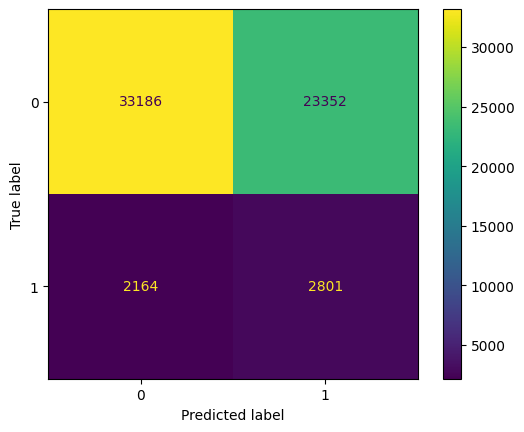

In [ ]:
disp_cm_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg)
disp_cm_log_reg.plot()
plt.show()

In [ ]:
roc_auc_log_reg = roc_auc_score(Y_test,y_prob[:,1])
print('ROC AUC score for Logistic Regression: ',roc_auc_log_reg)

ROC AUC score for Logistic Regression:  0.6031758764711785


In [ ]:
precision_log_reg = precision_score(Y_test, y_pred)
recall_log_reg = recall_score(Y_test, y_pred)

print('Logistic Regression precision: ',precision_log_reg)
print('Logistic Regression recall: ',recall_log_reg)

Logistic Regression precision:  0.10710052384047719
Logistic Regression recall:  0.5641490433031219


In [ ]:
log_reg_pr_auc = average_precision_score(Y_test, y_prob[:,1])

print('PR AUC score for Logistic Regression: ', log_reg_pr_auc)

PR AUC score for Logistic Regression:  0.11210163922556426


Random Forest

In [ ]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1,class_weight='balanced')
rf.fit(X_train, Y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [ ]:
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)

In [ ]:
cm_rf = confusion_matrix(Y_test, rf_pred)
print('Confusion matrix for Random Forest:\n',cm_rf)

Confusion matrix for Random Forest:
 [[56525    13]
 [ 4952    13]]


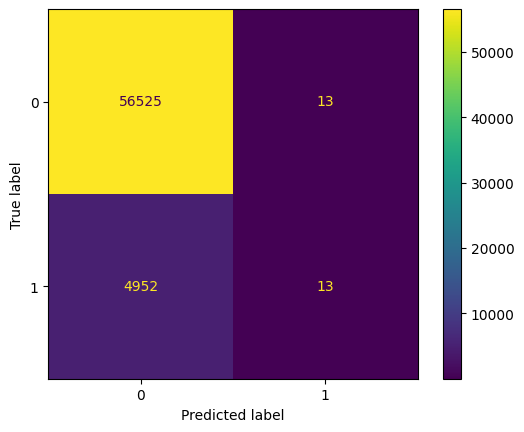

In [ ]:
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_cm.plot()
plt.show()

In [ ]:
roc_auc_rf = roc_auc_score(Y_test, rf_prob[:,1])
print('ROC AUC score for Random Forest: ',roc_auc_rf)

ROC AUC score for Random Forest:  0.7225013133606333


In [ ]:
precision_rf = precision_score(Y_test, rf_pred)
recall_rf = recall_score(Y_test, rf_pred)

print('Random Forest precision: ',precision_rf)
print('Random Forest recall: ',recall_rf)

Random Forest precision:  0.5
Random Forest recall:  0.0026183282980866062


In [ ]:
rf_pr_auc = average_precision_score(Y_test, rf_prob[:,1])

print('PR AUC score for Random Forest: ',rf_pr_auc)

PR AUC score for Random Forest:  0.20479382774711483


XGBoost

In [ ]:
xgb = XGBClassifier(random_state=42, use_label_encoder=False, class_weight = 'balanced', eval_metric='logloss')
xgb.fit(X_train, Y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:19:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              class_weight='balanced', colsample_bylevel=None,
              colsample_bynode=None, colsample_bytree=None, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, ...)

In [ ]:
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)

In [ ]:
cm_xgb = confusion_matrix(Y_test, xgb_pred)
print('Confusion matric for XGBoost:\n',cm_xgb)

Confusion matric for XGBoost:
 [[56364   174]
 [ 4781   184]]


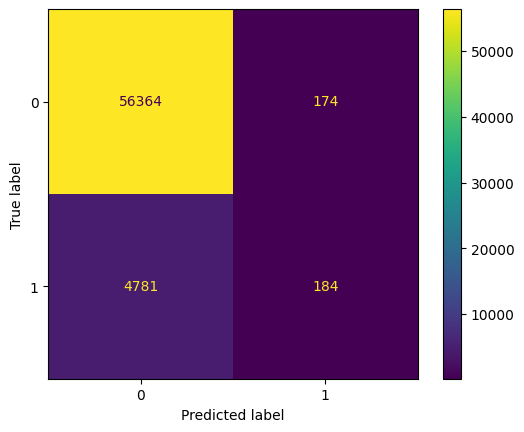

In [ ]:
disp_cm_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp_cm_xgb.plot()
plt.show()

In [ ]:
roc_auc_xgb = roc_auc_score(Y_test, xgb_prob[:,1])
print('ROC AUC score for XGBoost: ',roc_auc_xgb)

ROC AUC score for XGBoost:  0.7507390176172896


In [ ]:
xgb_precision = precision_score(Y_test, xgb_pred)
xgb_recall = recall_score(Y_test, xgb_pred)

print('XGBoost precision: ',xgb_precision)
print('XGBoost recall: ',xgb_recall)

XGBoost precision:  0.5139664804469274
XGBoost recall:  0.03705941591137966


In [ ]:
xgb_pr_auc = average_precision_score(Y_test, xgb_prob[:,1])

print('PR AUC score for XGBoost: ',xgb_pr_auc)

PR AUC score for XGBoost:  0.23758613029906142


# **Performance metrics comparison**

In [ ]:
roc_auc = [roc_auc_log_reg, roc_auc_rf, roc_auc_xgb]
pr_auc = [log_reg_pr_auc,rf_pr_auc, xgb_pr_auc]
prec = [precision_log_reg, precision_rf, xgb_precision]
recall = [recall_log_reg, recall_rf, xgb_recall]
model = ['Logistic Regression', 'Random Forest', 'XGBoost']

metrics_lst ={'Model': model,
              'ROC AUC': roc_auc,
              'PR AUC': pr_auc,
              'Precision': prec,
              'Recall': recall}

metrics = pd.DataFrame(metrics_lst)

metrics.set_index('Model')

,ROC AUC,PR AUC,Precision,Recall
Model,,,,
Logistic Regression,0.603176,0.112102,0.107101,0.564149
Random Forest,0.722501,0.204794,0.500000,0.002618
XGBoost,0.750739,0.237586,0.513966,0.037059



*   Logistic Regression: Recall is fairly high at 0.56, which means the model catches many defaulters, but it is not precise. Also, low ROC AUC suggests that the model does separate the two classes well.

*   Random Forest: Shows strong improvement. ROC AUC improves, denoting better than separation of classes. Precision significantly improves, signifying that the no of defaulters that the model predicts correctly has improved. Recall has dropped, denoting that fewer defaulters are being tagged among the entire population. However this can be improved by changing the threshold. Improvement in PR AUC suggests that Random Forest deals with minority class far better than Logistic Regression.


*   XGBoost: Significant improvement in ROC AUC, PR AUC and precision wrt to both the other models. Recall is low, but this is a threshold dependent metric which can be taken care of. XGBoost is a clear winner. **We will go ahead and model the dataset using XGBoost.**